# Representation Learning and Word Embeddings

In this workbook, I will explore word embeddings using Word2Vec and other techniques. The notebook will also visualize the learned embeddings and perform various tasks to understand the properties and applications of word embeddings.

We will:
1. Load pre-trained word embeddings using gensim.
2. Compute cosine similarity between word vectors.
3. Solve word analogy problems using word embeddings.
4. Visualize word embeddings using PCA.
5. Analyze the effect of singular/plural forms and comparative/superlative forms of words in the embedding space.


## Load Pre-trained Word Embeddings

After loading pre-trained word embeddings using the gensim library we'll also be able to get the embedding for a specific word and check its dimensionality.

In [ ]:
#!pip install --upgrade gensim
import gensim.downloader as api

# Load pre-trained word vectors
word_vectors = api.load("word2vec-google-news-300")
embedding_computer = word_vectors["computer"]

print(f"Embedding for 'computer': {embedding_computer}")
print(f"Dimension of the embedding: {embedding_computer.shape[0]}")

Embedding for 'computer': [ 1.07421875e-01 -2.01171875e-01  1.23046875e-01  2.11914062e-01
 -9.13085938e-02  2.16796875e-01 -1.31835938e-01  8.30078125e-02
  2.02148438e-01  4.78515625e-02  3.66210938e-02 -2.45361328e-02
  2.39257812e-02 -1.60156250e-01 -2.61230469e-02  9.71679688e-02
 -6.34765625e-02  1.84570312e-01  1.70898438e-01 -1.63085938e-01
 -1.09375000e-01  1.49414062e-01 -4.65393066e-04  9.61914062e-02
  1.68945312e-01  2.60925293e-03  8.93554688e-02  6.49414062e-02
  3.56445312e-02 -6.93359375e-02 -1.46484375e-01 -1.21093750e-01
 -2.27539062e-01  2.45361328e-02 -1.24511719e-01 -3.18359375e-01
 -2.20703125e-01  1.30859375e-01  3.66210938e-02 -3.63769531e-02
 -1.13281250e-01  1.95312500e-01  9.76562500e-02  1.26953125e-01
  6.59179688e-02  6.93359375e-02  1.02539062e-02  1.75781250e-01
 -1.68945312e-01  1.21307373e-03 -2.98828125e-01 -1.15234375e-01
  5.66406250e-02 -1.77734375e-01 -2.08984375e-01  1.76757812e-01
  2.38037109e-02 -2.57812500e-01 -4.46777344e-02  1.88476562e-01

## Compute Cosine Similarity

Here we're implementing a function to compute the cosine similarity between two vectors from scratch (i.e., without using built-in functions except `math.sqrt()`). 

Then using this function to compute the similarity between several pairs of words we'll get a better understanding of cosine similarity that's crucial for working with word embeddings and other vector representations.

I think the outputs we see below are very neat. 

In [ ]:
import numpy as np
import math

def cosine_similarity(vec1, vec2):
    # Dot Product over NormA * NormB
    DotProduct = np.dot(vec1, vec2)
    NormA = np.linalg.norm(vec1)
    NormB = np.linalg.norm(vec2)
    return DotProduct / (NormA * NormB)
    
# Compute similarity between pairs of words
words = [('computer', 'science'), ('boy', 'girl'), ('king', 'queen'), ('man', 'woman'), ('apple', 'orange'), ('cat', 'dog')]
for word1, word2 in words:
    vec1 = word_vectors[word1]
    vec2 = word_vectors[word2]
    similarity = cosine_similarity(vec1, vec2)
    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity}")

Cosine similarity between 'computer' and 'science': 0.3110199570655823
Cosine similarity between 'boy' and 'girl': 0.8543271422386169
Cosine similarity between 'king' and 'queen': 0.6510956883430481
Cosine similarity between 'man' and 'woman': 0.7664012312889099
Cosine similarity between 'apple' and 'orange': 0.3920345902442932
Cosine similarity between 'cat' and 'dog': 0.7609456777572632


## Solve Word Analogies

In this task, you will use the word embeddings to solve word analogy problems. For example, you can solve the analogy `queen: woman :: ?:man` by finding the word that is most similar to the result of the operation `queen - woman + man`.

Use gensim's built-in function `most_similar` to find the word most similar to the result of vector arithmetic operations

This task illustrated the power of word embeddings in capturing semantic relationships.

In [ ]:
# Solve word analogies
analogies = [
    ('queen', 'woman', 'man'),
    ('dad', 'man', 'woman'),
    ('paris', 'france', 'italy'),
    ('sun', 'day', 'night'),
    ('tree', 'forest', 'river'),
    ('happy', 'joy', 'sad')
]
for word1, word2, word3 in analogies:
    # word1 - word2 + word3
    result = word_vectors[word1] - word_vectors[word2] + word_vectors[word3]

    dist = word_vectors.most_similar(positive=[result], topn=5)
    your_answer = [word for word, score in dist if word not in (word1, word2, word3)][0]  #This was a claude suggestion, this was very cool
    
    print(f"{word1} - {word2} + {word3} = {your_answer} ")

queen - woman + man = king 
dad - man + woman = mom 
paris - france + italy = lohan 
sun - day + night = sunlight 
tree - forest + river = creek 
happy - joy + sad = disappointed 


## Visualize Word Embeddings

Next, we will visualize word embeddings using PCA (Principal Component Analysis). 

We will select a set of words, get their embeddings, and plot them in a 2D space. This visualization can help us in understanding the structure and relationships in the embedding space.

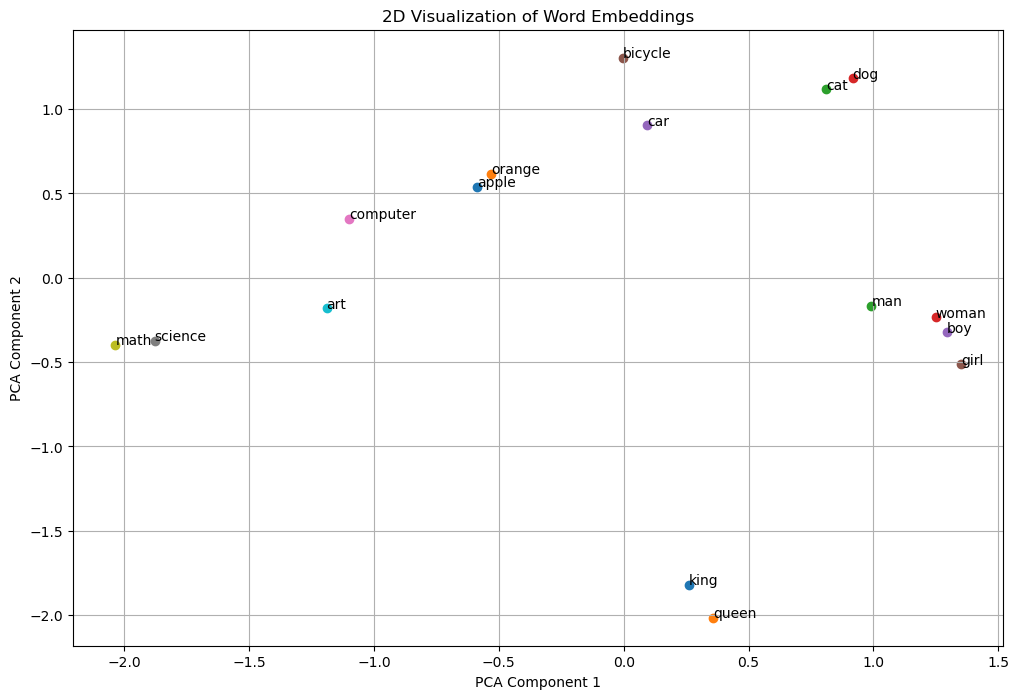

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# List of words to visualize
words_to_visualize = ['king', 'queen', 'man', 'woman', 'boy', 'girl', 'computer', 'science', 'math', 'art', 'apple', 'orange', 'cat', 'dog', 'car', 'bicycle']
embeddings = [word_vectors[word] for word in words_to_visualize]

# Reduce dimensionality
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot embeddings
plt.figure(figsize=(12, 8))
for i, word in enumerate(words_to_visualize):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1])
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D Visualization of Word Embeddings')
plt.grid(True)
plt.show()

## Analyze Singular and Plural Forms

Next, we will analyze the singular and plural forms of several nouns and their relations in the embedding space. We will select a set of words, get their embeddings, and visualize them. This can help understand how embeddings represent morphological variations.

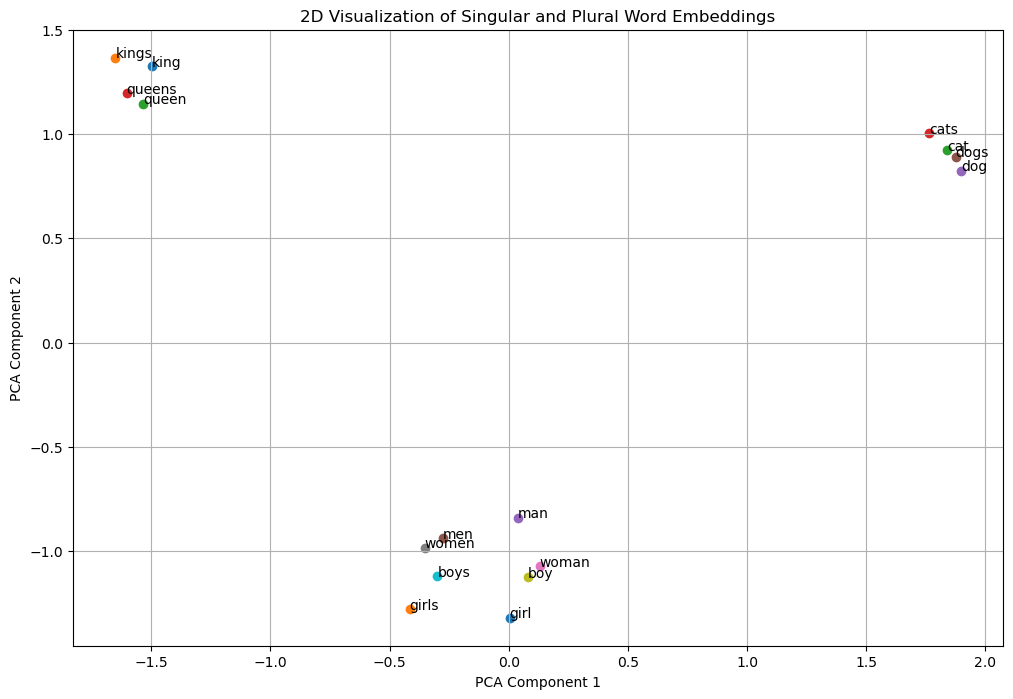

In [18]:
# List of singular and plural words
singular_plural_words = ['king', 'kings', 'queen', 'queens', 'man', 'men', 'woman', 'women', 'boy', 'boys', 'girl', 'girls', 'cat', 'cats', 'dog', 'dogs']
embeddings_singular_plural = [word_vectors[word] for word in singular_plural_words]

# Reduce dimensionality
embeddings_singular_plural_2d = pca.fit_transform(embeddings_singular_plural)

# Plot embeddings
plt.figure(figsize=(12, 8))
for i, word in enumerate(singular_plural_words):
    plt.scatter(embeddings_singular_plural_2d[i, 0], embeddings_singular_plural_2d[i, 1])
    plt.annotate(word, (embeddings_singular_plural_2d[i, 0], embeddings_singular_plural_2d[i, 1]))
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D Visualization of Singular and Plural Word Embeddings')
plt.grid(True)
plt.show()

## Analyze Adjectives and Their Forms

Next, we will analyze the comparative and superlative forms of several adjectives and their relations in the embedding space. We will select a set of words, get their embeddings, and visualize them.

This can help us in understanding how word embeddings capture comparative and superlative relations.

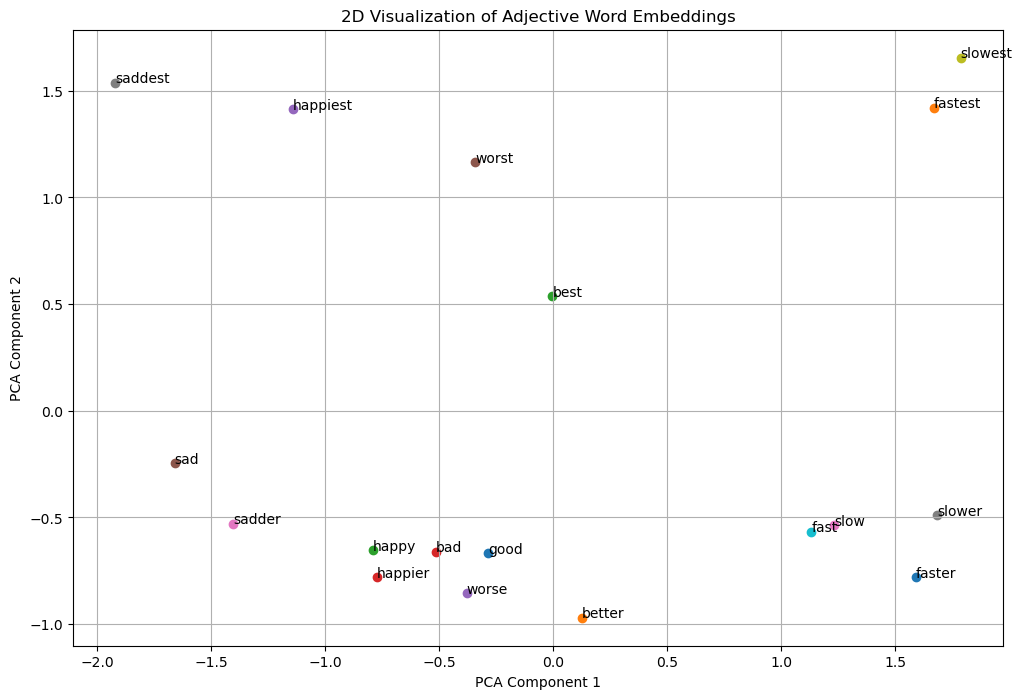

In [20]:
# List of adjectives and their comparative and superlative forms
adjectives = ['good', 'better', 'best', 'bad', 'worse', 'worst', 'slow', 'slower', 'slowest', 'fast', 'faster', 'fastest', 'happy', 'happier', 'happiest', 'sad', 'sadder', 'saddest']
embeddings_adjectives = [word_vectors[word] for word in adjectives]

# Reduce dimensionality
embeddings_adjectives_2d = pca.fit_transform(embeddings_adjectives)

# Plot embeddings
plt.figure(figsize=(12, 8))
for i, word in enumerate(adjectives):
    plt.scatter(embeddings_adjectives_2d[i, 0], embeddings_adjectives_2d[i, 1])
    plt.annotate(word, (embeddings_adjectives_2d[i, 0], embeddings_adjectives_2d[i, 1]))
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D Visualization of Adjective Word Embeddings')
plt.grid(True)
plt.show()


## Summary 



In the first plot, we can guess the theme pretty loosely around the patterns by which we group each word. How we may reference a person, a pet we may have, types of royalty. The second adds context, is it singular or plural, are we grouping on quantitative measures or qualitative measures. The last adds a layer to the previous, context can be viewed and the effect of maximizing a characteristic leads to a dsiruption in the grouping of the categorical features. 